<a href="https://colab.research.google.com/github/jonkrohn/ML-foundations/blob/master/notebooks/6-statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [218]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [219]:
sns.set_style('darkgrid')

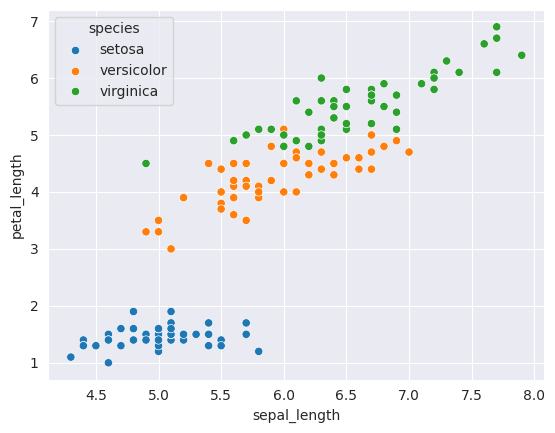

In [220]:
_ = sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=iris)

In [221]:
import pandas as pd

In [222]:
dummy = pd.get_dummies(iris.species, dtype = 'int64') # int64 dtype required to avoid ValueError when calling sm.OLS() below
dummy

,setosa,versicolor,virginica
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
145,0,0,1
146,0,0,1
147,0,0,1
148,0,0,1


In [223]:
y = iris.petal_length

In [224]:
X = pd.concat([iris.sepal_length, dummy.setosa, dummy.versicolor], axis=1)
X # virginia as "baseline" where setosa and versicolor are both 0

,sepal_length,setosa,versicolor
0,5.1,1,0
1,4.9,1,0
2,4.7,1,0
3,4.6,1,0
4,5.0,1,0
...,...,...,...
145,6.7,0,0
146,6.3,0,0
147,6.5,0,0
148,6.2,0,0


In [225]:
import statsmodels.api as sm

In [226]:
X = sm.add_constant(X)
X

,const,sepal_length,setosa,versicolor
0,1.0,5.1,1,0
1,1.0,4.9,1,0
2,1.0,4.7,1,0
3,1.0,4.6,1,0
4,1.0,5.0,1,0
...,...,...,...,...
145,1.0,6.7,0,0
146,1.0,6.3,0,0
147,1.0,6.5,0,0
148,1.0,6.2,0,0


In [227]:
model = sm.OLS(y, X)

In [228]:
result = model.fit()

In [229]:
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           petal_length   R-squared:                       0.975
Model:                            OLS   Adj. R-squared:                  0.974
Method:                 Least Squares   F-statistic:                     1890.
Date:                Wed, 11 Sep 2024   Prob (F-statistic):          1.46e-116
Time:                        19:56:33   Log-Likelihood:                -21.237
No. Observations:                 150   AIC:                             50.47
Df Residuals:                     146   BIC:                             62.52
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.3877      0.301      4.611      0.000       0.793       1.982
sepal_length     0.6321      0.045     13.962      0.000       0.543       0.722
setosa          -3.0900      0.091    -33.870      0.000      -3.270      -2.910
versicolor      -0.8799      0.064    -13.800      0.000      -1.006      -0.754
==============================================================================
Omnibus:                        0.652   Durbin-Watson:                   1.757
Prob(Omnibus):                  0.722   Jarque-Bera (JB):                0.310
Skew:                          -0.022   Prob(JB):                        0.856
Kurtosis:                       3.218   Cond. No.                         82.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Our earlier iris model, with sepal length as the only predictor of petal length, had $r^2 = 0.76$. In our latest iris model, a whopping 97% of the variance in petal length is explained by the predictors.

In [230]:
beta = result.params
beta

,0
const,1.387660
sepal_length,0.632110
setosa,-3.090002
versicolor,-0.879864


In [231]:
xline = np.linspace(4, 8, 1000)
vi_yline = beta['const'] + beta['sepal_length']*xline
se_yline = beta['const'] + beta['sepal_length']*xline + beta['setosa']
ve_yline = beta['const'] + beta['sepal_length']*xline + beta['versicolor']

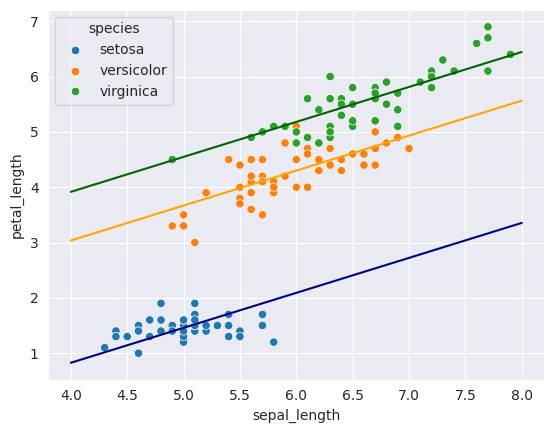

In [232]:
sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=iris)
plt.plot(xline, vi_yline, color='darkgreen')
plt.plot(xline, se_yline, color='darkblue')
_ = plt.plot(xline, ve_yline, color='orange')

Now using our refined model, such that it predicts the petal length of a *versicolor* iris with a 5.5cm-long sepal:

In [233]:
x_sepall_i = 5.5
x_setosa_i = 0
x_versic_i = 1

In [234]:
y_i = beta['const'] + beta['sepal_length']*x_sepall_i + beta['setosa']*x_setosa_i + beta['versicolor']*x_versic_i

In [235]:
y_i

3.984400080089945

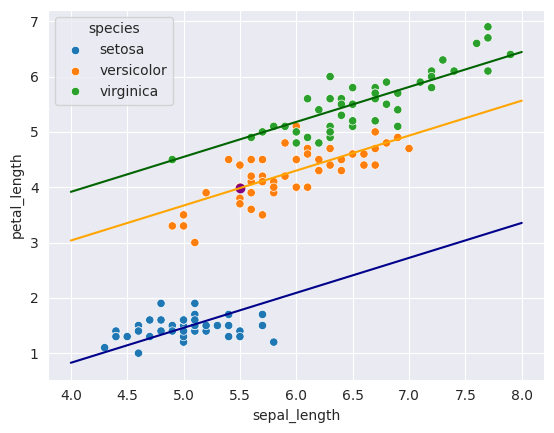

In [236]:
sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=iris)
plt.plot(xline, vi_yline, color='darkgreen')
plt.plot(xline, se_yline, color='darkblue')
plt.plot(xline, ve_yline, color='orange')
_ = plt.scatter(x_sepall_i, y_i, marker='o', color='purple')

...or a *virginica* with a sepal of the same length:

In [237]:
x_sepall_i = 5.5
x_setosa_i = 0
x_versic_i = 0 # the only change

In [238]:
x_i = np.array([1, x_sepall_i, x_versic_i, x_versic_i])

In [239]:
y_i = np.dot(beta, x_i)

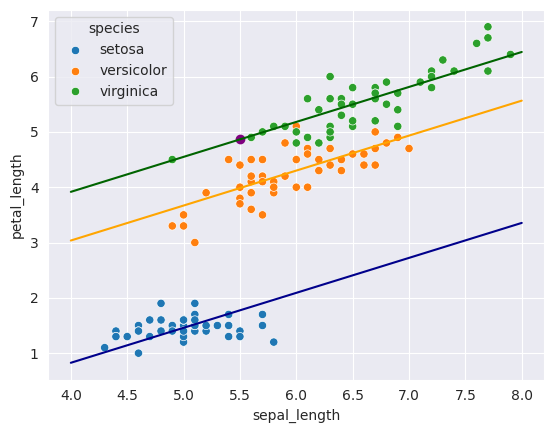

In [240]:
sns.scatterplot(x='sepal_length', y='petal_length', hue='species', data=iris)
plt.plot(xline, vi_yline, color='darkgreen')
plt.plot(xline, se_yline, color='darkblue')
plt.plot(xline, ve_yline, color='orange')
_ = plt.scatter(x_i[1], y_i, marker='o', color='purple')

(It is also possible to have the slope vary by categorical variable, not only the $y$-intercept. This is a *hierarchical linear model* and the classic text on it is [Gelman & Hill, 2006](https://amzn.to/3hoOevb).)